In [1]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Questions to explore

In [3]:
def read_results(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['rsa']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    # if there is a layer_name == Input, drop it and store the layer names in a list
    if 'layer_name' in df.columns:
        df = df[df['layer_name'] != 'Input']

    
    if metric == 'rsa': # return np array of [n_layers x n_sparsity_levels]
        res = df.iloc[:, 1:].to_numpy()
    
    return res

def get_layer_names(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['rsa']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    if 'layer_name' in df.columns:
        layer_names = df['layer_name'].to_list()
        layer_names = [name for name in layer_names if name != 'Input']
        return layer_names
    else:
        return None
    
def get_sparsity_levels(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['rsa']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    sparsity_levels = df.columns[1:].to_list() # first column is layer name
    sparsity_levels = [float(s.split('sparsity_')[1]) for s in sparsity_levels]
    return sparsity_levels

In [ ]:

# df1 = pd.read_csv(f'./results/vgg_rsa_svd_layerwise1.csv')
# df2  = pd.read_csv(f'./results/vgg_rsa_svd_layerwise2.csv')

# column_names = df2.columns.tolist()

# df2.drop(columns=['sparsity_0.8', 'sparsity_0.9', 'sparsity_1'], inplace=True)
# # join df2 to df1 on layer_name column and overwrite nan columns in df1 with values from df2. keep new columns from df2 on the right

# df = df1.merge(df2, on='layer_name', how='right')
# # rearrange columns to have df2 columns 
# df = df[['layer_name'] + [col for col in df2.columns if col != 'layer_name'] + [col for col in df1.columns if col not in df2.columns and col != 'layer_name']]

# df.to_csv(f'./results/vgg_rsa_svd_layerwise.csv', index=False)

### 



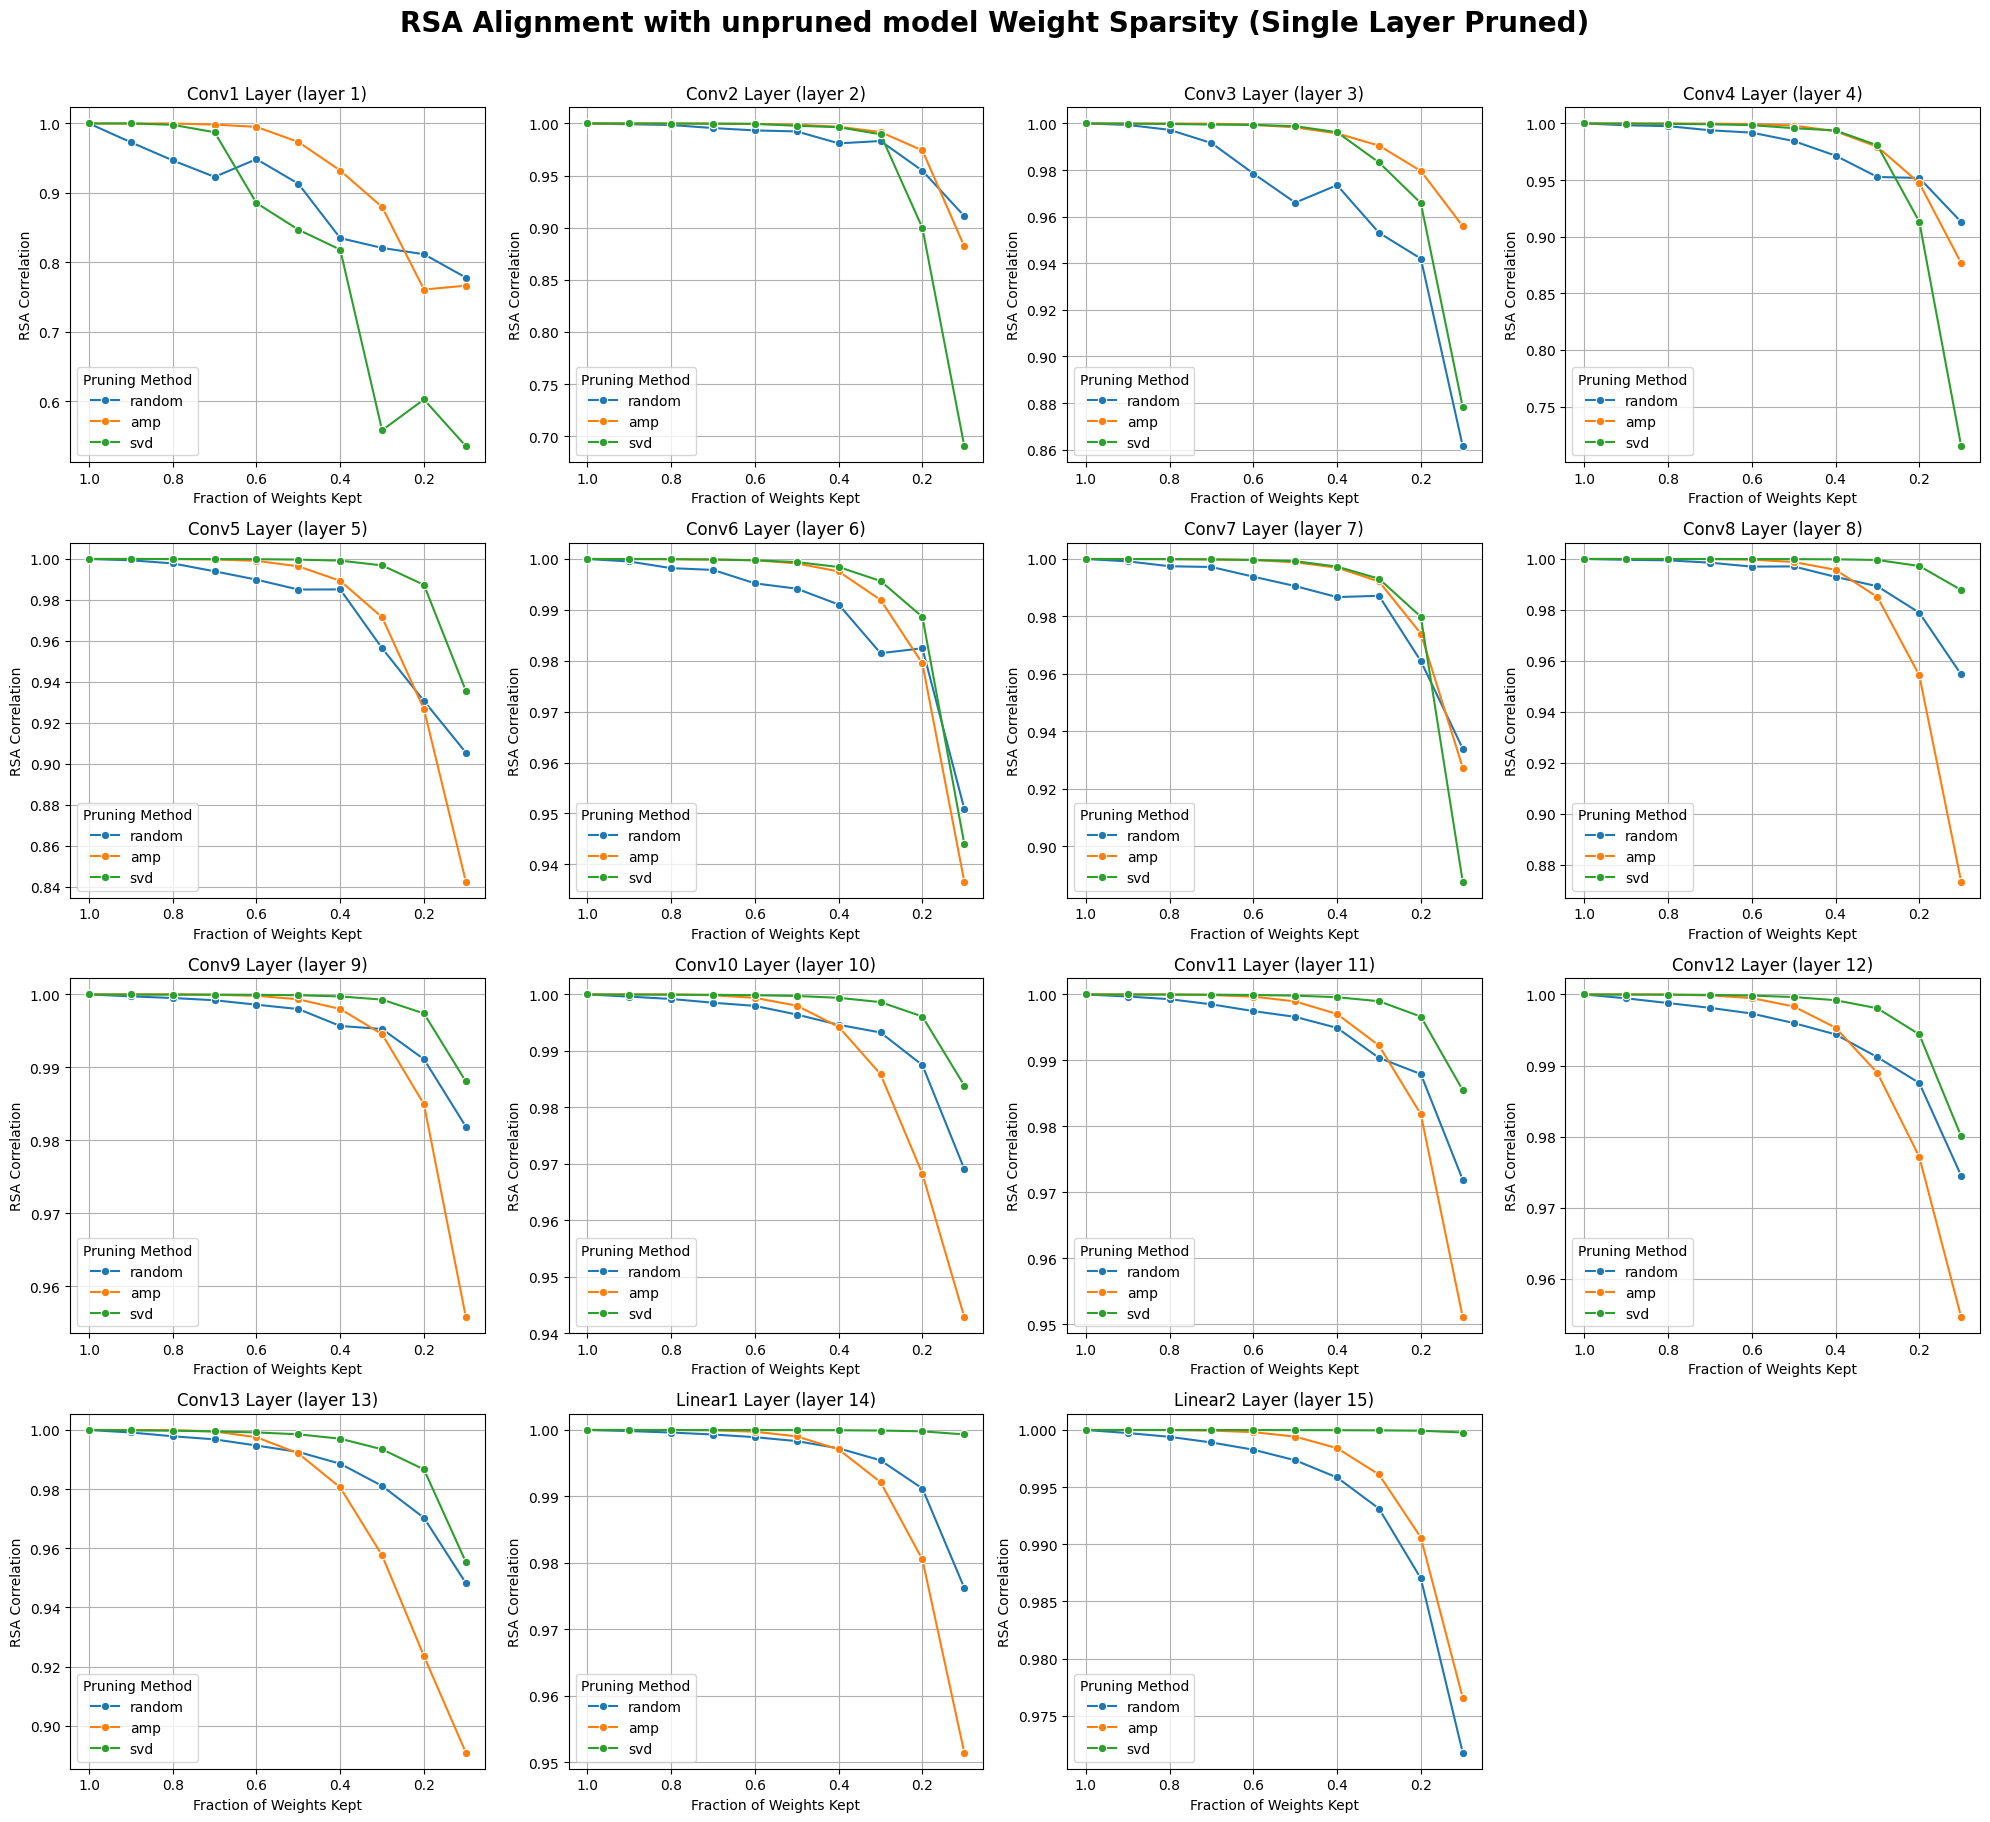

In [6]:
# subplots for each layer showing how the pca dim changes with sparsity level for each method (all 3 methods)
rsa_random_layerwise = read_results(prune_method='random', metric='rsa', prune_all=False) #[n_layers x n_sparsity_levels]
rsa_amp_layerwise = read_results(prune_method='amp', metric='rsa', prune_all=False)
rsa_svd_layerwise = read_results(prune_method='svd', metric='rsa', prune_all=False)

layer_names = get_layer_names(prune_method='random', metric='rsa', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='rsa', prune_all=False)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'rsa_corr', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['rsa_corr'] = np.concatenate([rsa_random_layerwise[i, :], rsa_amp_layerwise[i, :], rsa_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='rsa_corr', hue='method', marker='o', ax=ax)
        
        ax.set_title(f'{layer_name} Layer (layer {i+1})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.set_ylabel('RSA Correlation')
        ax.legend(title='Pruning Method')
        ax.grid()
        ax.invert_xaxis()
    else:
        ax.axis('off')

fig.suptitle("RSA Alignment with unpruned model Weight Sparsity (Single Layer Pruned)", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

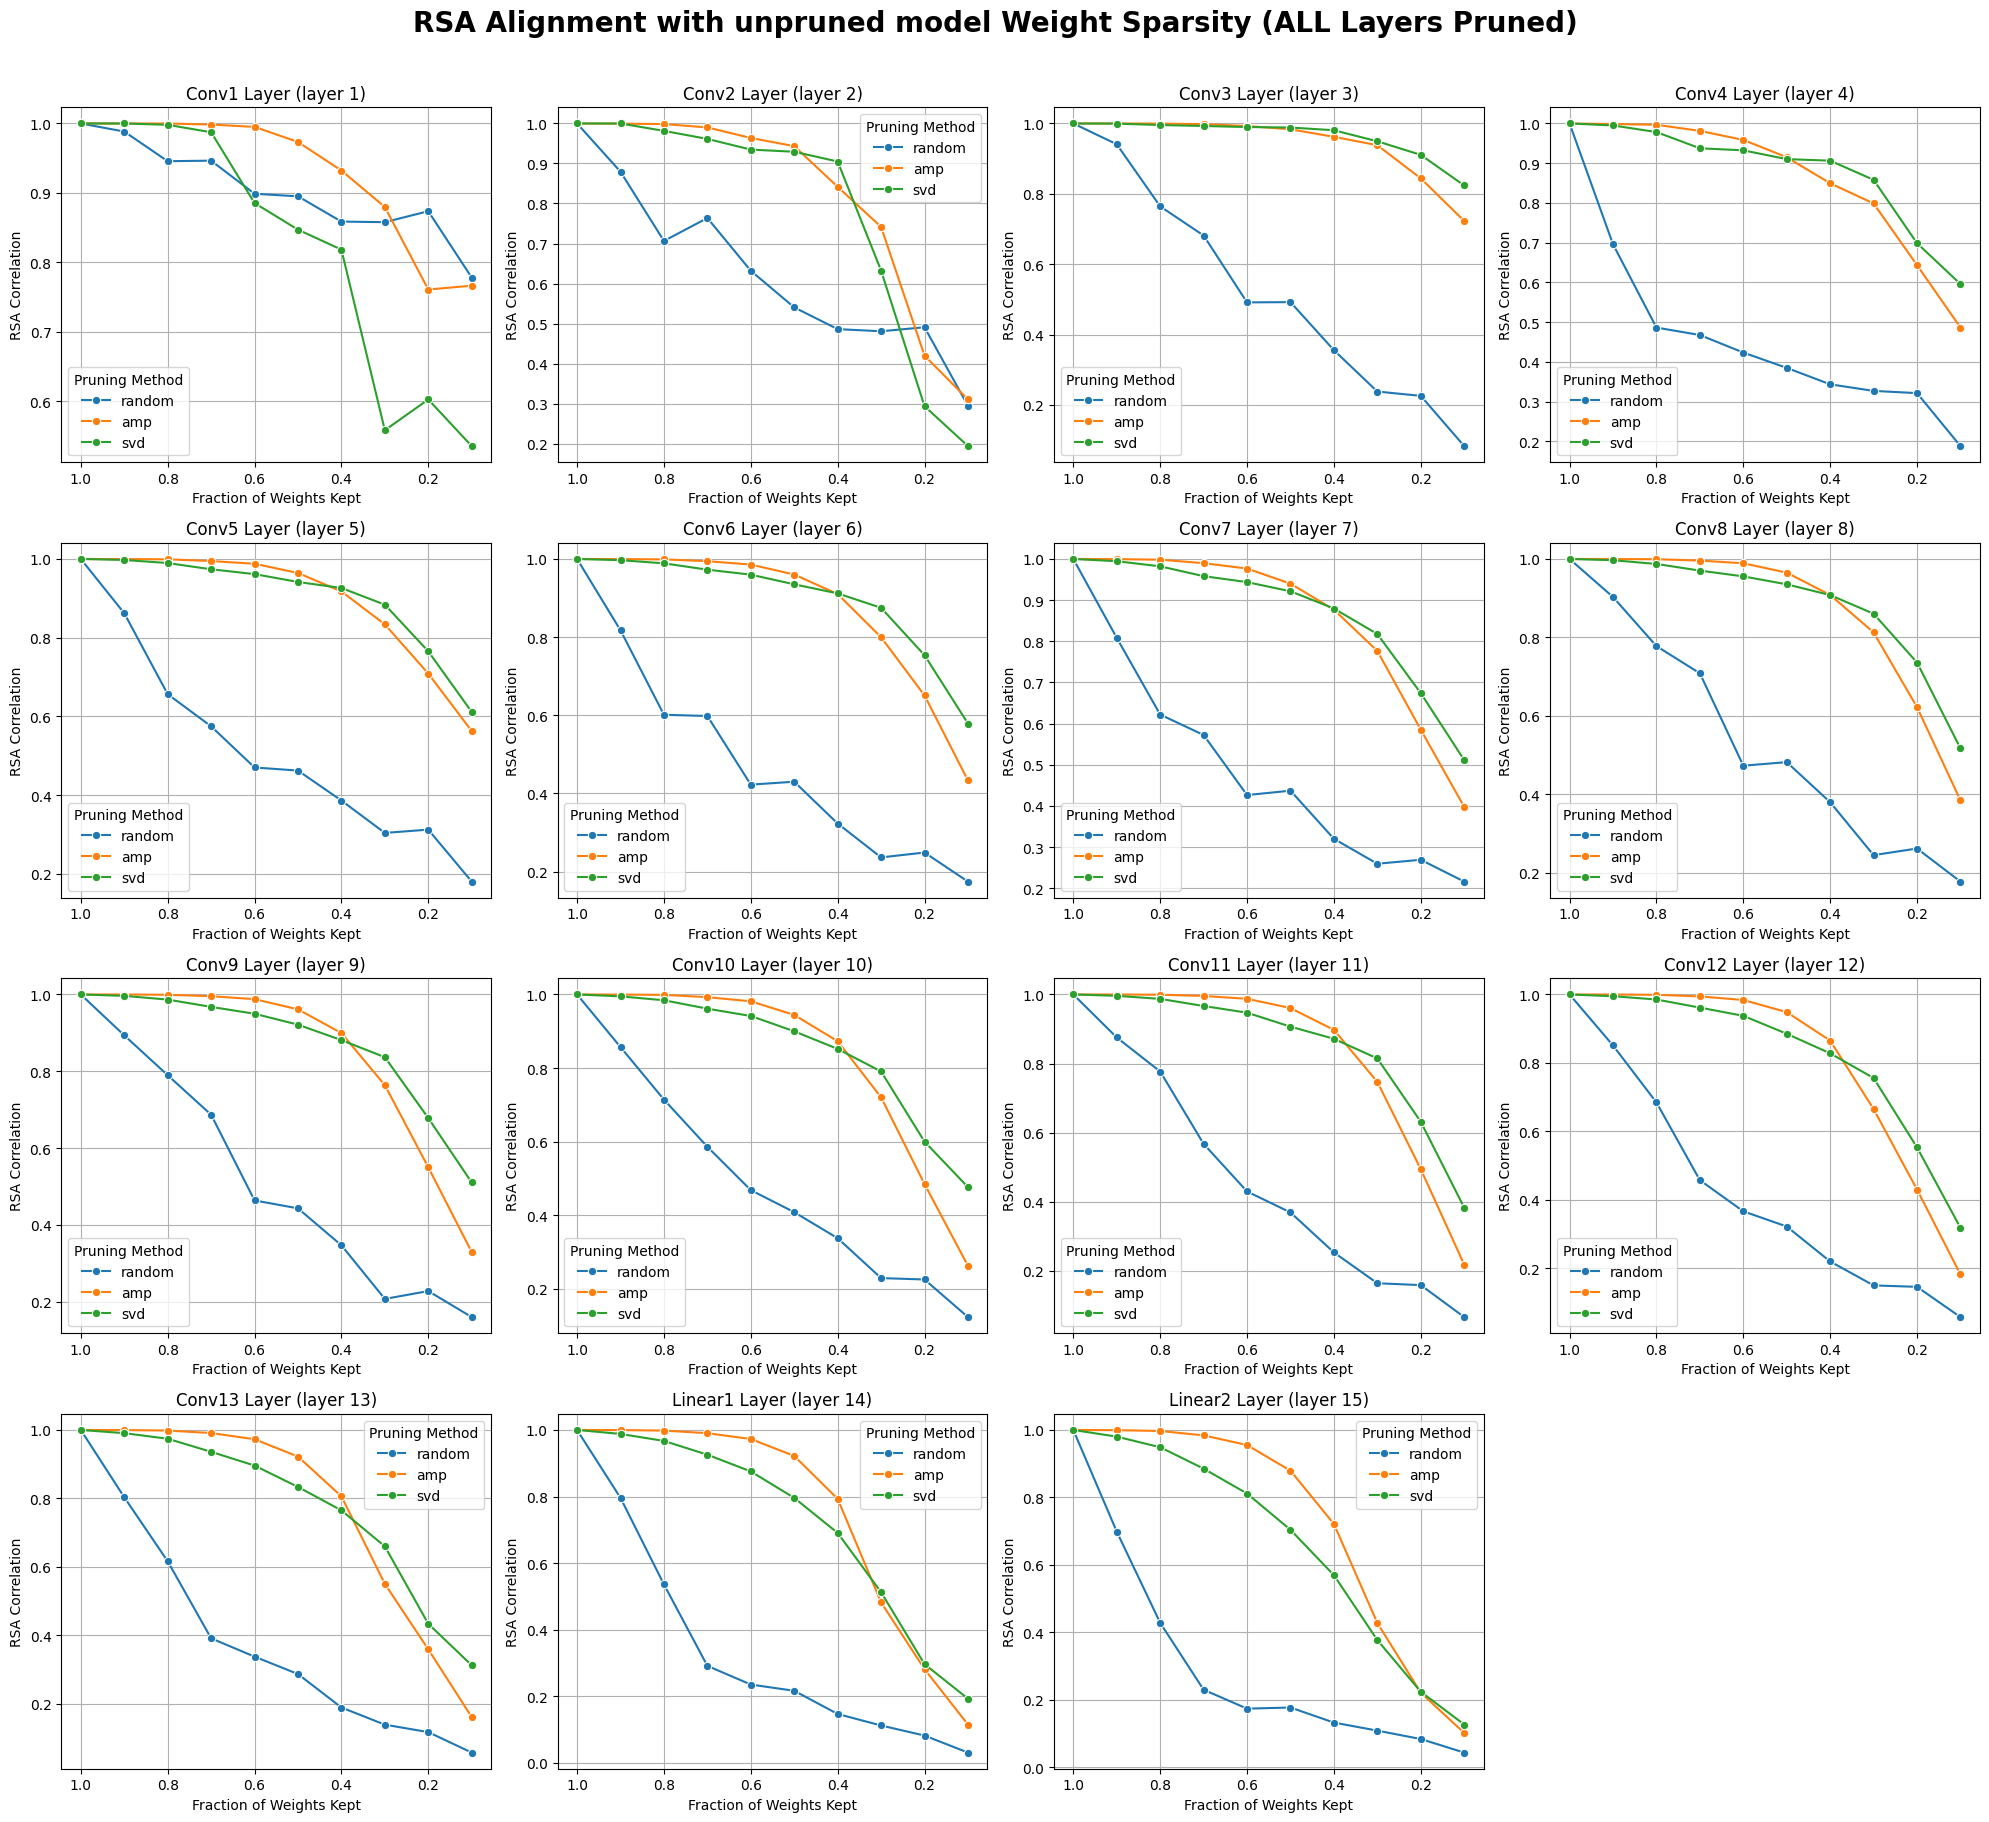

In [5]:
# subplots for each layer showing how the pca dim changes with sparsity level for each method (all 3 methods)
rsa_random_all= read_results(prune_method='random', metric='rsa', prune_all=True) #[n_layers x n_sparsity_levels]
rsa_amp_all= read_results(prune_method='amp', metric='rsa', prune_all=True)
rsa_svd_all= read_results(prune_method='svd', metric='rsa', prune_all=True)

layer_names = get_layer_names(prune_method='random', metric='rsa', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='rsa', prune_all=False)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'rsa_corr', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['rsa_corr'] = np.concatenate([rsa_random_all[i, :], rsa_amp_all[i, :], rsa_svd_all[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='rsa_corr', hue='method', marker='o', ax=ax)
        
        ax.set_title(f'{layer_name} Layer (layer {i+1})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.set_ylabel('RSA Correlation')
        ax.legend(title='Pruning Method')
        ax.grid()
        ax.invert_xaxis()
    else:
        ax.axis('off')

fig.suptitle("RSA Alignment with unpruned model Weight Sparsity (ALL Layers Pruned)", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()